# Double check the W_jacox coarsening

In [1]:
import xarray as xr
import numpy as np
from scipy.ndimage import binary_erosion, binary_dilation
from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
def coastal_band_mask(ds, var='u10', target_width_km=111):
    """
    Create a coastal band mask with uniform cross-shore width in km.
    """
    da = ds[var]
    if 'time' in da.dims:
        da = da.mean(dim='time')

    valid2d = np.isfinite(da).values.astype(bool)
    lat_vals = ds['lat'].values
    lon_vals = ds['lon'].values
    dlon = np.abs(lon_vals[1] - lon_vals[0])  # grid spacing in degrees

    # Find coastline (easternmost valid cell per row)
    band = np.zeros_like(valid2d, dtype=bool)

    for j in range(valid2d.shape[0]):
        row = valid2d[j, :]
        ocean_cols = np.where(row)[0]
        if len(ocean_cols) == 0:
            continue

        # Coast = easternmost valid cell
        i_coast = ocean_cols[-1]

        # How many cells = target_width_km at this latitude?
        A = 6371.0  # km
        dx_km = A * np.cos(np.deg2rad(lat_vals[j])) * np.deg2rad(dlon)
        n_cells = int(np.round(target_width_km / dx_km))

        # Fill n_cells westward from coast
        i_start = max(i_coast - n_cells, 0)
        band[j, i_start:i_coast + 1] = True

    # Only keep cells that are actually ocean
    band = band & valid2d

    da_mask = xr.DataArray(band, dims=('lat', 'lon'),
                           coords={'lat': ds['lat'], 'lon': ds['lon']})
    return da_mask

In [4]:
# Seasonality
def seasonality(data):
    return data.groupby('time.month').mean(dim='time')


In [7]:
def lat_band_mean(f, lat_top_start=-4, lat_top_end=-17):
    """
    Jacox-style box average: area-weighted mean over each 1° band.
    """
    A = 6371000.0
    results = []
    lat_band_centers = []

    for lat_north in tqdm(range(lat_top_start, lat_top_end, -1)):
        lat_south = lat_north - 1
        f_band = f.sel(lat=slice(lat_south, lat_north))

        if f_band.sizes.get("lat", 0) == 0:
            continue

        # Compute cell areas as weights (dx varies with latitude)
        lat_vals = f_band.lat.values
        dlon = np.abs(np.diff(f_band.lon.values[:2])[0]) if len(f_band.lon) > 1 else 0.08
        dlat = np.abs(np.diff(lat_vals[:2])[0]) if len(lat_vals) > 1 else 0.08

        # Area of each cell: dx(lat) * dy
        cos_lat = np.cos(np.deg2rad(lat_vals))
        cell_area = A * np.deg2rad(dlat) * A * cos_lat * np.deg2rad(dlon)
        weights = xr.DataArray(cell_area, dims='lat', coords={'lat': lat_vals})

        # Area-weighted mean over lat and lon
        f_weighted = f_band.weighted(weights).mean(dim=('lat', 'lon'))
        results.append(f_weighted)
        lat_band_centers.append(0.5 * (lat_south + lat_north))

    f_out = xr.concat(results, dim="lat_band")
    f_out = f_out.assign_coords(lat_band=np.array(lat_band_centers))
    return f_out

In [58]:
wmld = xr.open_dataset('W_mld_Croco.nc').compute()
mask = coastal_band_mask(wmld, 'WMLD', 250)  # ~111 km cross-shore

wmld = wmld.where(mask).sel(lon=slice(-85,None),lat=slice(-16.1,-5))
wmld

<xarray.Dataset> Size: 91MB
Dimensions:  (time: 432, lat: 135, lon: 194)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -16.03 -15.95 -15.87 ... -5.242 -5.159 -5.076
Data variables:
    WMLD     (time, lat, lon) float64 91MB nan nan nan nan ... nan nan nan nan

In [59]:
w_j = lat_band_mean(wmld,0,-20)
w_j

100%|████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 227.52it/s]


<xarray.Dataset> Size: 45kB
Dimensions:   (lat_band: 12, time: 432)
Coordinates:
  * time      (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat_band  (lat_band) float64 96B -5.5 -6.5 -7.5 -8.5 ... -14.5 -15.5 -16.5
Data variables:
    WMLD      (lat_band, time) float64 41kB 3.197e-06 3.09e-06 ... 9.708e-06

In [60]:
# ============================================================
# 3. Find coastal and offshore boundary longitudes per latitude
# ============================================================
valid = np.isfinite(wmld.WMLD.isel(time=0))
valid_e = valid.shift(lon=-1).fillna(False).astype(bool)
valid_w = valid.shift(lon=+1).fillna(False).astype(bool)

coast_mask = valid & (~valid_e)      # easternmost valid cell (coast)
offshore_mask = valid & (~valid_w)   # westernmost valid cell (offshore edge)

lat_all = wmld.lat.values
lon_all = wmld.lon.values

coast_lons = np.full(len(lat_all), np.nan)
offshore_lons = np.full(len(lat_all), np.nan)

for j in range(len(lat_all)):
    cols_e = np.where(coast_mask.isel(lat=j).values)[0]
    if len(cols_e) > 0:
        coast_lons[j] = lon_all[cols_e[0]]
    cols_w = np.where(offshore_mask.isel(lat=j).values)[0]
    if len(cols_w) > 0:
        offshore_lons[j] = lon_all[cols_w[0]]

In [61]:
A = 6371000.0
widths = np.full(len(lat_all), np.nan)
for j in range(len(lat_all)):
    if np.isfinite(coast_lons[j]) and np.isfinite(offshore_lons[j]):
        widths[j] = A * np.cos(np.deg2rad(lat_all[j])) * np.deg2rad(np.abs(coast_lons[j] - offshore_lons[j]))

widths_da = xr.DataArray(widths, dims='lat', coords={'lat': lat_all}, name='cross_shore_width')

widths_da

<xarray.DataArray 'cross_shore_width' (lat: 135)> Size: 1kB
array([249361.12603398, 249461.05953828, 249560.54534994, 249659.5825108 ,
       249758.17006607, 249856.30706435, 249953.99255769, 250051.22560157,
       250148.00525495, 250244.33058029, 250340.20064353, 250435.61451419,
       250530.57126529, 250625.06997348, 250719.10971896, 250812.68958558,
       250905.80866081, 250998.46603579, 251090.66080533, 251182.39206794,
       251273.65892586, 251364.46048507, 251454.79585531, 251544.66415009,
       251634.06448675, 251722.99598644, 251811.45777414, 251899.44897871,
       251986.9687329 , 252074.01617334, 252160.59044061, 252246.69067922,
       252332.31603765, 252417.46566836, 252502.13872781, 252586.3343765 ,
       252670.05177896, 252753.29010378, 252836.04852364, 252918.32621532,
       253000.12235973, 253081.43614189, 253162.26675101, 253242.61338047,
       253322.47522785, 253401.85149494, 253480.74138777, 253559.14411662,
       253637.05889605, 253714.48494491, 253791.42148636, 253867.86774788,
       253943.8229613 , 254019.28636285, 254094.25719309, 254168.73469701,
       254242.71812402, 254316.20672798, 254389.19976717, 254461.69650437,
       254533.69620686, 245512.15535547, 245580.62297078, 245648.60920907,
       245716.11338129, 245783.13480278, 245849.67279331, 245915.72667712,
       245981.29578289, 246046.3794438 , 246110.97699752, 246175.08778623,
       246238.71115664, 246301.84646003, 246364.4930522 , 246426.65029356,
       246488.31754909, 246549.49418839, 246610.17958569, 246670.37311985,
       246730.07417437, 246789.28213746, 246847.99640197, 246906.21636547,
       246963.94143025, 247021.17100332, 247077.90449643, 247134.1413261 ,
       247189.88091361, 247245.12268504, 247299.86607125, 247354.11050794,
       247407.85543562, 247461.10029965, 247513.84455026, 247566.08764252,
       247617.82903641, 247669.0681968 , 247719.80459346, 247770.03770111,
       247819.76699937, 247868.99197285, 247917.71211109, 247965.92690862,
       248013.63586496, 248060.83848463, 248107.53427715, 248153.72275709,
       248199.40344403, 248244.57586263, 248289.23954259, 248333.39401868,
       248377.03883077, 248420.17352382, 248462.79764791, 248504.91075821,
       248546.51241506, 248587.60218391, 248628.17963537, 248668.24434523,
       248707.79589443, 248746.83386913, 248785.35786064, 248823.36746551,
       248860.86228549, 248897.84192757, 248934.30600396, 248970.25413213,
       249005.6859348 , 249040.60103996, 249074.99908085, 249108.87969604,
       249142.24252934, 249175.08722992, 249207.41345221])
Coordinates:
  * lat      (lat) float64 1kB -16.03 -15.95 -15.87 ... -5.242 -5.159 -5.076

100%|████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 124.43it/s]


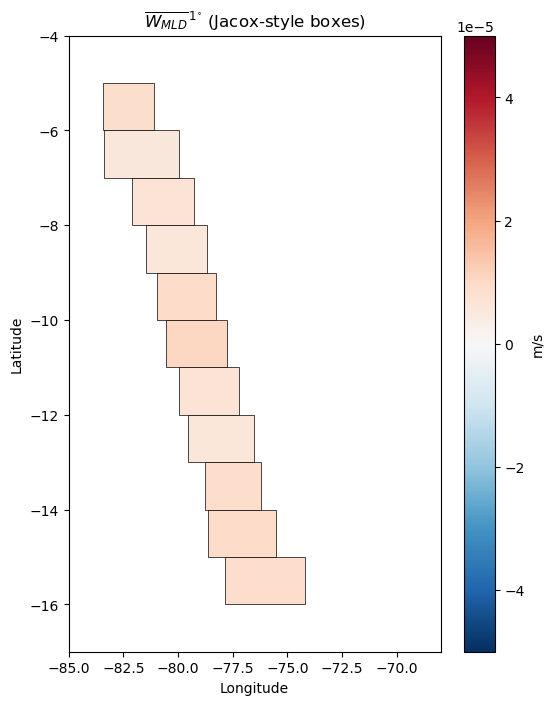

In [62]:
from matplotlib.patches import Rectangle as Rect

wmld_box = lat_band_mean(wmld.WMLD, lat_top_start=-5, lat_top_end=-16)
wmld_box_mean = wmld_box.mean('time')

fig, ax = plt.subplots(figsize=(6, 8))

for i, lb in enumerate(wmld_box_mean.lat_band.values):
    lat_s = lb - 0.5
    lat_n = lb + 0.5

    # Get the lon range for this band from your strip boundaries
    band_mask = (lat_all >= lat_s) & (lat_all <= lat_n)
    lw = np.nanmin(offshore_lons[band_mask])
    le = np.nanmax(coast_lons[band_mask])

    val = float(wmld_box_mean.sel(lat_band=lb).values)

    rect = Rect((lw, lat_s), le - lw, 1.0,
                facecolor=plt.cm.RdBu_r(plt.Normalize(-5e-5, 5e-5)(val)),
                edgecolor='black', linewidth=0.5)
    ax.add_patch(rect)

ax.set_xlim(-85, -68)
ax.set_ylim(-17, -4)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(r'$\overline{W_{MLD}}^{\,1^{\circ}}$ (Jacox-style boxes)')

# Add colorbar
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=plt.Normalize(-5e-5, 5e-5))
plt.colorbar(sm, ax=ax, label='m/s')
plt.show()

100%|████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 148.69it/s]


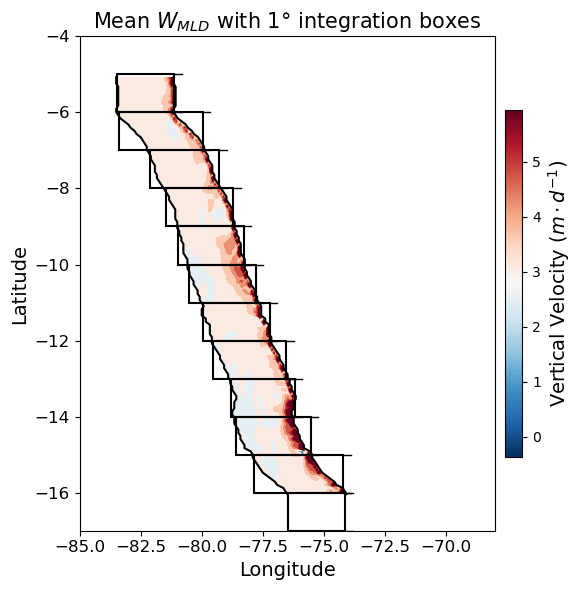

In [63]:
from matplotlib.patches import Rectangle as Rect
from matplotlib.collections import PatchCollection
import matplotlib.pyplot as plt
import numpy as np

# Compute box mean
wmld_box = lat_band_mean(wmld.WMLD, lat_top_start=-4, lat_top_end=-17)
wmld_box_mean = wmld_box.mean('time')

# Get full-res mean for background
wmld_full_mean = (wmld*60*60*24).WMLD.mean('time')

fig, ax = plt.subplots(figsize=(6, 6))

# Plot full-resolution W_mld as background
wmld_full_mean.plot.contourf(ax=ax, cmap='RdBu_r', vmin=-5, vmax=5,levels=11, add_colorbar=False)
ax.plot(coast_lons+0.05, lat_all, label='coast',color='black')
ax.plot(offshore_lons-0.05, lat_all, label='offshore',color='black')

# Draw Jacox-style boxes with outlines
patches = []
colors = []

for lb in wmld_box_mean.lat_band.values:
    lat_s = lb - 0.5
    lat_n = lb + 0.5

    # Get strip boundaries for this band
    band_mask = (lat_all >= lat_s) & (lat_all <= lat_n)
    valid_offshore = offshore_lons[band_mask]
    valid_coast = coast_lons[band_mask]

    valid_offshore = valid_offshore[np.isfinite(valid_offshore)]
    valid_coast = valid_coast[np.isfinite(valid_coast)]

    if len(valid_offshore) == 0 or len(valid_coast) == 0:
        continue

    lw = np.min(valid_offshore)
    le = np.max(valid_coast)

    # Draw box outline
    rect = Rect((lw, lat_s), le - lw, lat_n - lat_s,
                facecolor='none', edgecolor='black', linewidth=1.5)
    ax.add_patch(rect)

    # Draw tick marks at box boundaries (like Jacox's figure)
    # Short horizontal lines at the coast edge
    tick_len = 0.3  # degrees
    ax.plot([le, le + tick_len], [lat_s, lat_s], 'k-', lw=1)
    ax.plot([le, le + tick_len], [lat_n, lat_n], 'k-', lw=1)

# Colorbar
sm = plt.cm.ScalarMappable(cmap='RdBu_r',
                           norm=plt.Normalize(
                               vmin=float(wmld_full_mean.quantile(0.02)),
                               vmax=float(wmld_full_mean.quantile(0.98))))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label(r'Vertical Velocity ($m \cdot d^{-1}$)', fontsize=14)

ax.set_xlim(-85, -68)
ax.set_ylim(-17, -4)
ax.set_xlabel('Longitude', fontsize=14)
ax.set_ylabel('Latitude', fontsize=14)
ax.set_title(r'Mean $W_{MLD}$ with 1° integration boxes', fontsize=15)
ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

In [64]:
wmld__ = xr.open_dataset('W_mld_Croco.nc').compute()
wmld__ = wmld__.where(wmld__!=0,np.nan)

Text(0.5, 1.0, 'coast / offshore boundary detection')

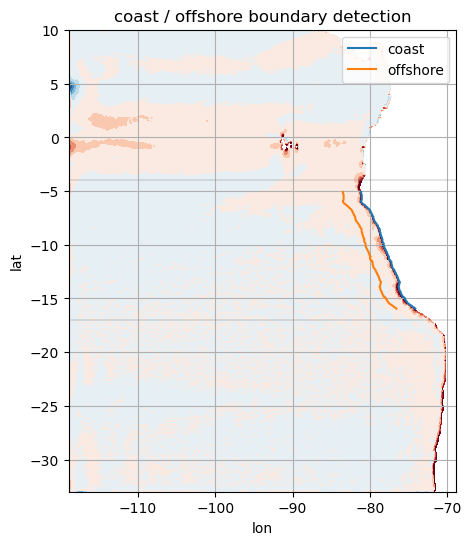

In [38]:
fig, ax = plt.subplots(figsize=(5, 6))
wmld_full_mean.plot.contourf(ax=ax, cmap='RdBu_r', vmin=-5, vmax=5,levels=11, add_colorbar=False)
ax.plot(coast_lons+0.05, lat_all, label='coast')
ax.plot(offshore_lons-0.05, lat_all, label='offshore')
ax.set_xlabel('lon'); ax.set_ylabel('lat')
ax.axhline(-4,  color='grey', lw=0.3)
ax.axhline(-17, color='grey', lw=0.3)
ax.legend(); ax.grid(True)
ax.set_title('coast / offshore boundary detection')

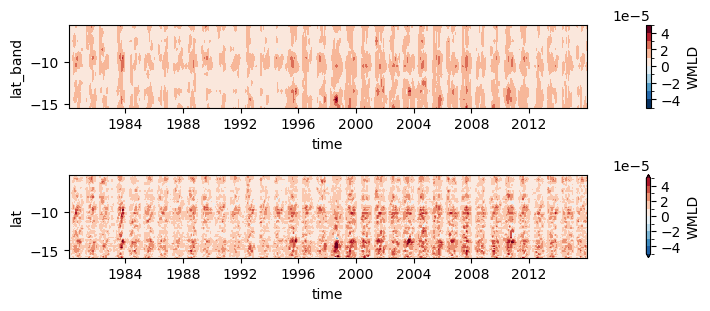

In [39]:
fig,ax = plt.subplots(2,1,figsize=(7,3),constrained_layout=True)

w_j.WMLD.plot.contourf(vmin=-5e-5,vmax=5e-5,levels=11,cmap='RdBu_r',ax=ax[0])
wmld.WMLD.mean(dim='lon').plot.contourf(vmin=-5e-5,vmax=5e-5,levels=11,cmap='RdBu_r',ax=ax[1],y='lat')

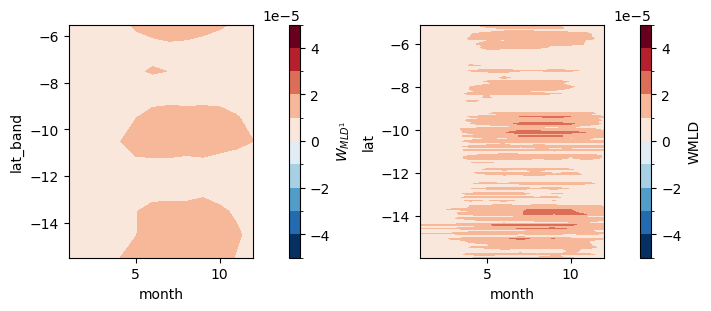

In [40]:
fig,ax = plt.subplots(1,2,figsize=(7,3),constrained_layout=True)

seasonality(w_j).WMLD.sel(lat_band=slice(-5,-16)).rename('$W_{MLD^{1}}$').plot.contourf(x='month',vmin=-5e-5,vmax=5e-5,levels=11,cmap='RdBu_r',ax=ax[0])
seasonality(wmld).WMLD.sel(lat=slice(-16,-5)).mean(dim=('lon')).plot.contourf(x='month',vmin=-5e-5,vmax=5e-5,levels=11,cmap='RdBu_r',ax=ax[1])


In [41]:
# fig,ax = plt.subplots(1,2,figsize=(7,3),constrained_layout=True)

# (w_j*60*60*24).WMLD.sel(lat_band=slice(-5,-16)).mean('time').plot.contourf(ax=ax[0],vmin=-5,vmax=5,levels=11,cmap='RdBu_r')
# (wmld*60*60*24).WMLD.sel(lat=slice(-16,-5)).mean('time').plot.contourf(ax=ax[1],vmin=-5,vmax=5,levels=11,cmap='RdBu_r')

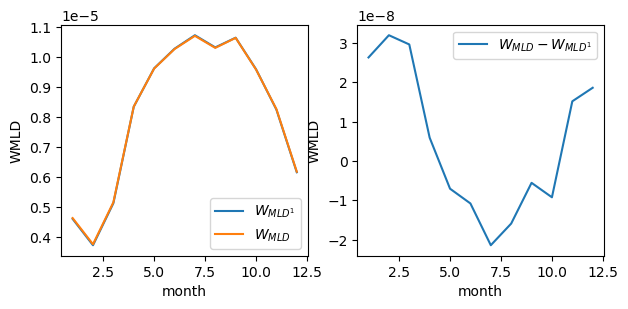

In [42]:
fig,ax =plt.subplots(1,2,figsize=(7,3))

seasonality(w_j).WMLD.sel(lat_band=slice(-5,-16)).mean(dim=('lat_band')).plot(label='$W_{MLD^{1}}$',ax=ax[0])
seasonality(wmld).WMLD.sel(lat=slice(-16,-5)).mean(dim=('lat','lon')).plot(label='$W_{MLD}$',ax=ax[0])

(seasonality(wmld).WMLD.sel(lat=slice(-16,-5)).mean(
    dim=('lat','lon')) - seasonality(w_j).WMLD.sel(
    lat_band=slice(-5,-16)).mean(dim=('lat_band'))).plot(ax=ax[1], label='$W_{MLD} - W_{MLD^{1}}$')

ax[0].legend()
ax[1].legend()

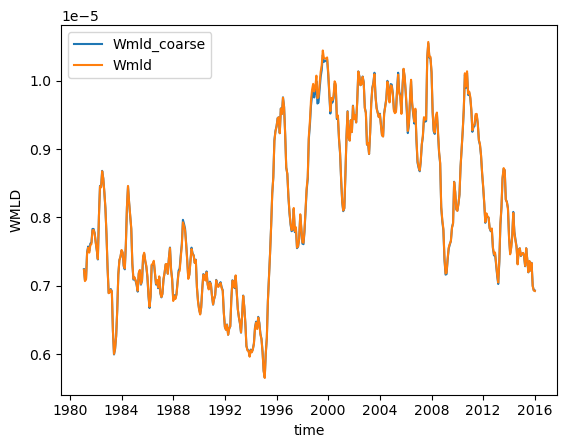

In [43]:
w_j.WMLD.sel(lat_band=slice(-5,-16)).mean(dim=('lat_band')).rolling(time=13).mean().plot(label='Wmld_coarse')
wmld.WMLD.sel(lat=slice(-16,-5)).mean(dim=('lat','lon')).rolling(time=13).mean().plot(label='Wmld')
plt.legend()

## Methods Plot

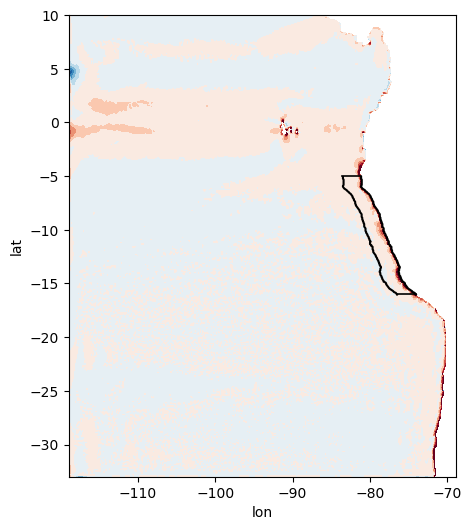

In [68]:
fig, ax = plt.subplots(figsize=(5, 6))
wmld_full_mean.plot.contourf(ax=ax, cmap='RdBu_r', vmin=-5, vmax=5,levels=11, add_colorbar=False)
ax.plot(coast_lons+0.05, lat_all,color='Black')
ax.plot(offshore_lons-0.05, lat_all,color='Black')
ax.set_xlabel('lon'); ax.set_ylabel('lat')
# ============================================================
# Cross-shore lines at exact integer latitudes
# ============================================================
target_lats = [-5, -16]

for lat0 in target_lats:
    j = np.argmin(np.abs(lat_all - lat0))
    lon_c = coast_lons[j]
    lon_o = offshore_lons[j]
            
    dx = 1.05 * abs(lon_c - lon_o)
    x0 = lon_c - np.sign(lon_c - lon_o) * dx
    x1 = lon_c
    
    ax.plot([x0, x1], [lat0, lat0], color='black', lw=1.2, zorder=5)
    
# ax.set_title('coast / offshore boundary detection')

Lat  -5 → closest index    134 | coast=-81.20 | offshore=-83.45
Lat -16 → closest index      0 | coast=-74.12 | offshore=-76.45


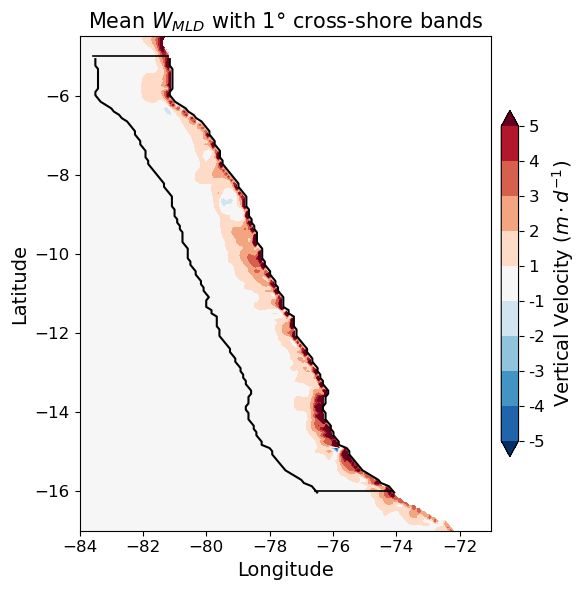

In [66]:
from matplotlib.colors import TwoSlopeNorm 
from matplotlib.ticker import FormatStrFormatter

# ============================================================
# Compute data
# ============================================================
# wmld_box = lat_band_mean(wmld.WMLD, lat_top_start=-4, lat_top_end=-17)
# wmld_box_mean = wmld_box.mean('time')
wmld_full_mean = (wmld__ * 60 * 60 * 24).WMLD.mean('time')

# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(figsize=(6,6))

# --- Background field with proper levels ---
vmin=-5; vmax=5
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

levels=np.linspace(vmin,vmax,10)

cf = wmld_full_mean.plot.contourf(
    ax=ax,
    cmap='RdBu_r',
    levels=levels,
    vmin=vmin, vmax=vmax,norm=norm,
    add_colorbar=False
)

# --- Proper colorbar linked to contourf ---
cbar = plt.colorbar(cf, ax=ax, pad=0.02,shrink=0.7)
cbar.set_label(r'Vertical Velocity ($m \cdot d^{-1}$)', fontsize=14)

# ticks every 0.5 (already matches levels, but enforce clean formatting)
# cbar.set_ticks(np.arange(-5, 5, 1)) 
cbar.ax.tick_params(labelsize=12)

# --- Coast and offshore limits ---
ax.plot(coast_lons + 0.05, lat_all, color='black', label='coast')
ax.plot(offshore_lons - 0.05, lat_all, color='black', label='offshore')

# ============================================================
# Cross-shore lines at exact integer latitudes
# ============================================================
target_lats = [-5, -16]

for lat0 in target_lats:
    j = np.argmin(np.abs(lat_all - lat0))
    lon_c = coast_lons[j]
    lon_o = offshore_lons[j]
    
    print(f"Lat {lat0:3d} → closest index {j:6d} | coast={lon_c:.2f} | offshore={lon_o:.2f}")  # DEBUG
    
    if not (np.isfinite(lon_c) and np.isfinite(lon_o)):
        print(f"    → Skipped (NaN values)")
        continue
        
    dx = 1.05 * abs(lon_c - lon_o)
    x0 = lon_c - np.sign(lon_c - lon_o) * dx
    x1 = lon_c
    
    ax.plot([x0, x1], [lat0, lat0], color='black', lw=1.2, zorder=5)

# ============================================================
# Axes formatting
# ============================================================
ax.set_xlim(-84, -71)
ax.set_ylim(-17, -4.5)

ax.set_xlabel('Longitude', fontsize=14)
ax.set_ylabel('Latitude', fontsize=14)
ax.set_title(r'Mean $W_{MLD}$ with 1° cross-shore bands', fontsize=15)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.tick_params(labelsize=12)

plt.tight_layout()
# plt.grid(True)
plt.show()